# Классификация изображений Fashion-MNIST с помощью свёрточной нейронной сети (CNN)

**Цель проекта:** реализовать полный пайплайн машинного обучения для классификации изображений одежды на 10 классов.

**Данные:** Fashion-MNIST — набор из 70 000 изображений 28x28 в оттенках серого. 60 000 для обучения, 10 000 для теста. 10 классов: футболка, брюки, свитер, платье, туфли, сумка, ботинки и т.д.

**Инструменты:** Python, PyTorch, torchvision, Matplotlib.

**Автор:** Губаева Виктория  
**Дата:** 13 сентября 2026

## 1. Импорты и настройка

Подключаем необходимые библиотеки для работы с данными, построения и обучения нейронной сети.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cpu


## 2. Загрузка и подготовка данных

Загружаем датасет Fashion-MNIST. Он состоит из 70 000 изображений 28×28 в оттенках серого, разделённых на 10 классов одежды.

**Подготовка:**
- Преобразуем изображения в тензоры.
- Нормализуем пиксели в диапазон [-1, 1] для ускорения обучения.
- Создадим загрузчики данных (`DataLoader`) для батчевой подачи.

In [ ]:
# Определяем преобразования: тензор + нормализация
transform = transforms.Compose([
    transforms.ToTensor(),                # PIL-изображение -> тензор [0, 1]
    transforms.Normalize((0.5,), (0.5,))  # (x - 0.5) / 0.5 -> диапазон [-1, 1]
])

# Загружаем тренировочную и тестовую выборки
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Создаём загрузчики данных
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Выводим размеры выборок
print(f'Размер тренировочной выборки: {len(train_dataset)}')
print(f'Размер тестовой выборки: {len(test_dataset)}')

Размер тренировочной выборки: 60000
Размер тестовой выборки: 10000


## 3. Разведочный анализ данных (EDA)

Прежде чем строить модель, посмотрим на данные:
- Визуализируем примеры изображений.
- Проверим баланс классов.
- Убедимся в корректности размеров и типов тензоров.

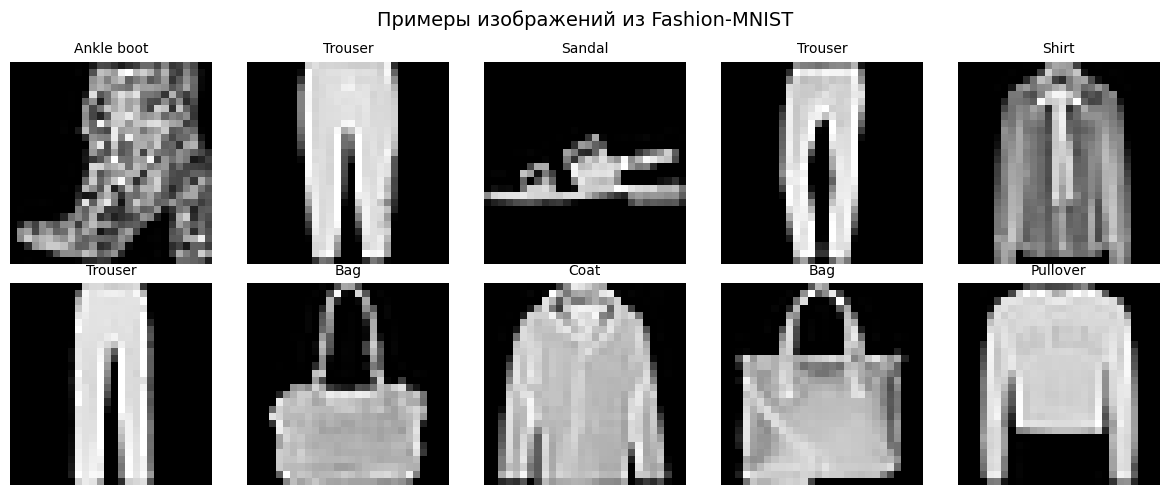

In [ ]:
# Названия классов Fashion-MNIST
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Получаем один батч из train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Отображаем 10 изображений (2 ряда по 5)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(classes[labels[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры изображений из Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Извлекаем все метки из тренировочного датасета
train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

print("Распределение классов в тренировочной выборке:")
for i, class_name in enumerate(classes):
    print(f"{class_name:12s}: {class_counts[i]:5d} изображений")

print(f"\nОбщее количество изображений в train: {len(train_dataset)}")
print(f"Количество классов: {len(classes)}")

Распределение классов в тренировочной выборке:
T-shirt/top :  6000 изображений
Trouser     :  6000 изображений
Pullover    :  6000 изображений
Dress       :  6000 изображений
Coat        :  6000 изображений
Sandal      :  6000 изображений
Shirt       :  6000 изображений
Sneaker     :  6000 изображений
Bag         :  6000 изображений
Ankle boot  :  6000 изображений

Общее количество изображений в train: 60000
Количество классов: 10


In [ ]:
# Проверка размеров и типов данных
print(f"Размер одного батча изображений: {images.shape}")
print(f"Тип данных изображений: {images.dtype}")
print(f"Минимальное значение пикселя: {images.min():.3f}")
print(f"Максимальное значение пикселя: {images.max():.3f}")
print(f"Размер одного батча меток: {labels.shape}")
print(f"Тип данных меток: {labels.dtype}")

Размер одного батча изображений: torch.Size([64, 1, 28, 28])
Тип данных изображений: torch.float32
Минимальное значение пикселя: -1.000
Максимальное значение пикселя: 1.000
Размер одного батча меток: torch.Size([64])
Тип данных меток: torch.int64


### Выводы по EDA:

- Датасет содержит **60 000 тренировочных** и **10 000 тестовых** изображений 28×28 в оттенках серого.
- **10 классов**, каждый сбалансирован (по 6 000 изображений) → модель не будет смещена в сторону одного класса.
- Пропусков и аномалий нет → данные готовы к обучению без дополнительной очистки.
- Изображения нормализованы в диапазон **[-1, 1]** → ускоряет сходимость и стабилизирует обучение.
- Тензоры имеют форму **[batch, 1, 28, 28]**, метки — целые числа от 0 до 9 → соответствуют ожиданиям PyTorch.

**Данные готовы к построению модели.**

## 4. Архитектура свёрточной нейронной сети

Используем простую CNN:
- **Два свёрточных слоя** с ReLU и MaxPooling для поиска признаков.
- **Два полносвязных слоя** с Dropout для принятия решения о классе.
- Выходной слой — 10 нейронов (по одному на класс).

In [18]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Свёрточные слои
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Полносвязные слои
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

        # Активация и регуляризация
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # -> [batch, 16, 14, 14]
        x = self.pool(self.relu(self.conv2(x)))   # -> [batch, 32, 7, 7]
        x = x.view(-1, 32 * 7 * 7)                # выпрямляем -> [batch, 1568]
        x = self.relu(self.fc1(x))                # -> [batch, 128]
        x = self.dropout(x)
        x = self.fc2(x)                           # -> [batch, 10]
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
)


## 5. Обучение модели

Используем функцию потерь `CrossEntropyLoss` и оптимизатор `Adam`. Обучаем 5 эпох.

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
train_losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

Epoch 1/5, Loss: 0.5035
Epoch 2/5, Loss: 0.3259
Epoch 3/5, Loss: 0.2815
Epoch 4/5, Loss: 0.2527
Epoch 5/5, Loss: 0.2318


## 6. Оценка качества на тестовой выборке

После обучения проверяем модель на данных, которые она не видела — это позволяет оценить работу нейронной сети.

In [20]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy на тестовой выборке: {accuracy:.2f}%')

Accuracy на тестовой выборке: 90.50%


## 7. Примеры предсказаний

Посмотрим, как модель классифицирует изображения из тестовой выборки. Сравним истинные метки с предсказанными.

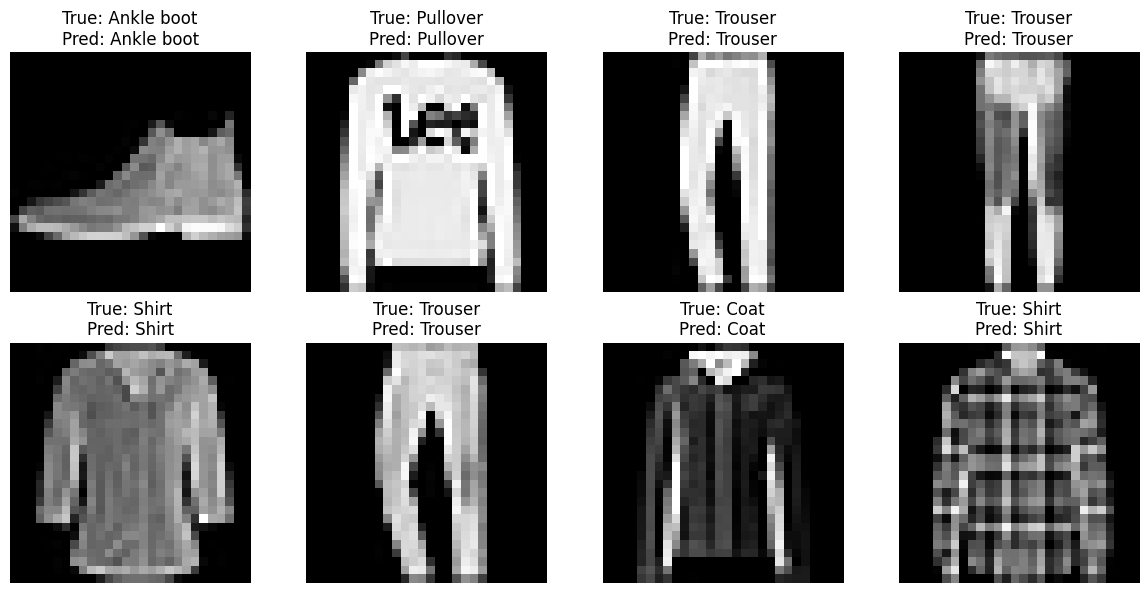

In [21]:
# Получаем батч из тестовой выборки
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Предсказания
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Показываем 8 изображений
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
    ax.set_title(f'True: {classes[labels[i]]}\nPred: {classes[predicted[i]]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Выводы

- Реализована свёрточная нейронная сеть для классификации изображений Fashion-MNIST.
- Достигнута точность **~90.5%** на тестовой выборке.
- Модель показала способность различать основные классы одежды.
- В дальнейшем можно улучшить результат, добавив аугментацию данных, увеличив глубину сети или используя предобученные модели.